# 06. Global Explanations: Partial Dependence, ICE, and ALE

The previous notebook used decision trees to make model behavior readable through path logic. That is a local-to-segment view: one account follows one path into one terminal leaf.

This notebook moves to **global explanation plots**. Instead of asking why one account received one prediction, we ask how a fitted model's predictions tend to move as a feature changes. Three tools are central:

- **Partial dependence plots (PDPs)**: average predicted response after replacing one feature with grid values.
- **Individual conditional expectation (ICE) plots**: one response curve per observation.
- **Accumulated local effects (ALE) plots**: accumulated local changes within the observed feature distribution.

The central theme is that global explanations are not causal effects. They summarize the fitted prediction function. That makes them powerful for model audit, stakeholder communication, and debugging, but dangerous when they are read as interventions.


## Learning Objectives

By the end of this notebook, you should be able to:

1. Define PDP, ICE, centered ICE, and ALE as mathematical summaries of a fitted prediction function.
2. Explain why PDP averages can hide heterogeneous model behavior.
3. Diagnose when PDPs create unrealistic feature combinations under correlated inputs.
4. Compute PDP, ICE, and ALE curves from model predictions.
5. Compare global explanation plots for a nonlinear decision model.
6. Use ALE to summarize local model changes while respecting the empirical support of a feature.
7. Separate model-response explanations from causal or policy claims.
8. Translate global explanations into decision-science questions for model review.


In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 240)
np.random.seed(2030)

TARGET = 'needs_specialist_review'
FEATURES = [
    'open_tickets_30d',
    'recent_incidents_90d',
    'integration_complexity',
    'usage_volatility',
    'training_completion',
    'product_adoption',
    'executive_sponsor',
    'enterprise_segment',
    'international_region',
    'pooled_support_motion',
]

FEATURE_LABELS = {
    'open_tickets_30d': 'Open tickets in last 30 days',
    'recent_incidents_90d': 'Recent incidents in last 90 days',
    'integration_complexity': 'Integration complexity',
    'usage_volatility': 'Usage volatility',
    'training_completion': 'Training completion',
    'product_adoption': 'Product adoption',
    'executive_sponsor': 'Executive sponsor present',
    'enterprise_segment': 'Enterprise segment',
    'international_region': 'International region',
    'pooled_support_motion': 'Pooled support motion',
}


## 1. What A Global Explanation Estimates

Let $\hat f(x)$ be a fitted model that returns a predicted probability or score. Split the feature vector into a feature of interest $x_j$ and all remaining features $x_{-j}$.

The **partial dependence function** for feature $j$ is

$$
\widehat{PD}_j(z)
= \frac{1}{n}\sum_{i=1}^n \hat f(z, x_{i,-j}).
$$

This asks: if every observation were evaluated at the same value $z$ for feature $j$, while keeping every other feature at its observed value, what would the average model prediction be?

That is a useful model audit question with a narrow interpretation. The notation $\hat f(z, x_{i,-j})$ describes a query to the fitted model at a constructed feature vector. It is not evidence that we intervened on the world.

The construction is the source of both the power and the danger. PDPs are easy to explain, but when features are correlated, they may average predictions over combinations that rarely occur in the data.


## 2. Synthetic Decision Case: Specialist Review Risk

We use a customer-success decision setting. A team must decide which accounts should be routed to proactive specialist review. The model predicts `needs_specialist_review`.

The data-generating process is deliberately structured so that several features are correlated:

| Relationship | Why it matters for global explanations |
|---|---|
| Training completion and product adoption are positively correlated | PDPs can pair low training with high adoption, or high training with low adoption, even when those combinations are unusual |
| Open tickets and recent incidents are correlated | A global plot for one burden variable may partially reflect the other |
| Enterprise segment affects complexity and ticket burden | Subgroup behavior may differ from the overall average |
| Executive sponsorship affects training and adoption | Model-response curves can mix operational maturity with governance context |

This design lets us see why PDP, ICE, and ALE answer related but different questions.


In [2]:
# Section focus: 2. Synthetic Decision Case: Specialist Review Risk.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -35, 35)))


def make_explanation_dataset(n=6800, seed=2030):
    """Construct the explanation dataset helper used in the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(['growth', 'mid-market', 'enterprise'], size=n, p=[0.48, 0.34, 0.18])
    region = rng.choice(['North', 'South', 'West', 'International'], size=n, p=[0.32, 0.22, 0.29, 0.17])
    support_motion = rng.choice(['reactive', 'pooled', 'dedicated'], size=n, p=[0.51, 0.33, 0.16])

    enterprise_segment = (segment == 'enterprise').astype(int)
    international_region = (region == 'International').astype(int)
    pooled_support_motion = (support_motion == 'pooled').astype(int)
    dedicated_support_motion = (support_motion == 'dedicated').astype(int)

    maturity = np.clip(
        rng.beta(3.2, 2.3, size=n)
        + 0.10 * enterprise_segment
        + 0.08 * dedicated_support_motion
        - 0.07 * pooled_support_motion,
        0.02,
        0.98,
    )

    integration_complexity = np.clip(
        rng.normal(3.8 + 1.0 * (segment == 'mid-market') + 1.9 * enterprise_segment + 0.35 * international_region, 1.15, n),
        1.0,
        10.0,
    )

    executive_sponsor = rng.binomial(
        1,
        np.clip(0.18 + 0.24 * (segment == 'mid-market') + 0.52 * enterprise_segment + 0.22 * maturity, 0.04, 0.94),
        size=n,
    )

    training_completion = np.clip(
        0.22
        + 0.57 * maturity
        + 0.12 * executive_sponsor
        - 0.08 * pooled_support_motion
        - 0.05 * international_region
        + rng.normal(0, 0.10, n),
        0.02,
        0.99,
    )

    usage_volatility = np.clip(
        rng.gamma(shape=2.0, scale=0.42, size=n)
        + 0.18 * pooled_support_motion
        + 0.09 * international_region
        + 0.06 * enterprise_segment
        - 0.15 * training_completion,
        0.02,
        4.5,
    )

    product_adoption = np.clip(
        0.13
        + 0.66 * training_completion
        + 0.10 * executive_sponsor
        - 0.028 * integration_complexity
        - 0.11 * usage_volatility
        + rng.normal(0, 0.09, n),
        0.02,
        0.99,
    )

    open_tickets_30d = rng.poisson(
        np.clip(1.0 + 1.1 * enterprise_segment + 0.75 * pooled_support_motion + 0.28 * integration_complexity - 1.15 * product_adoption, 0.15, None)
    )

    recent_incidents_90d = rng.poisson(
        np.clip(0.10 + 0.20 * open_tickets_30d + 0.46 * usage_volatility + 0.15 * international_region, 0.02, None)
    )

    low_training_low_adoption = ((training_completion < 0.48) & (product_adoption < 0.42)).astype(int)
    burden_spike = ((open_tickets_30d >= 5) & (recent_incidents_90d >= 2)).astype(int)
    volatile_complex = ((usage_volatility > 1.35) & (integration_complexity > 5.6)).astype(int)

    logit = (
        -4.55
        + 0.20 * open_tickets_30d
        + 0.48 * recent_incidents_90d
        + 0.19 * integration_complexity
        + 0.88 * usage_volatility
        - 1.40 * training_completion
        - 1.30 * product_adoption
        - 0.52 * executive_sponsor
        + 0.24 * enterprise_segment
        + 0.23 * international_region
        + 0.24 * pooled_support_motion
        + 1.35 * low_training_low_adoption
        + 0.70 * burden_spike
        + 0.52 * volatile_complex
    )

    needs_specialist_review = rng.binomial(1, sigmoid(logit), size=n)

    return pd.DataFrame(
        {
            'segment': segment,
            'region': region,
            'support_motion': support_motion,
            'maturity': maturity,
            'open_tickets_30d': open_tickets_30d,
            'recent_incidents_90d': recent_incidents_90d,
            'integration_complexity': integration_complexity,
            'usage_volatility': usage_volatility,
            'training_completion': training_completion,
            'product_adoption': product_adoption,
            'executive_sponsor': executive_sponsor,
            'enterprise_segment': enterprise_segment,
            'international_region': international_region,
            'pooled_support_motion': pooled_support_motion,
            'low_training_low_adoption': low_training_low_adoption,
            'burden_spike': burden_spike,
            'volatile_complex': volatile_complex,
            'needs_specialist_review': needs_specialist_review,
        }
    )


df = make_explanation_dataset()
train_df, test_df = train_test_split(df, test_size=0.30, stratify=df[TARGET], random_state=2030)

X_train = train_df[FEATURES].reset_index(drop=True)
y_train = train_df[TARGET].reset_index(drop=True)
X_test = test_df[FEATURES].reset_index(drop=True)
y_test = test_df[TARGET].reset_index(drop=True)

summary = pd.DataFrame(
    [
        {'quantity': 'Rows', 'value': len(df)},
        {'quantity': 'Train rows', 'value': len(train_df)},
        {'quantity': 'Test rows', 'value': len(test_df)},
        {'quantity': 'Specialist-review rate', 'value': df[TARGET].mean()},
        {'quantity': 'Correlation: training and adoption', 'value': df[['training_completion', 'product_adoption']].corr().iloc[0, 1]},
        {'quantity': 'Correlation: tickets and incidents', 'value': df[['open_tickets_30d', 'recent_incidents_90d']].corr().iloc[0, 1]},
        {'quantity': 'Low-training and low-adoption segment share', 'value': df['low_training_low_adoption'].mean()},
        {'quantity': 'Burden-spike segment share', 'value': df['burden_spike'].mean()},
    ]
)

segment_summary = (
    df.groupby('segment', as_index=False)
    .agg(
        rows=(TARGET, 'size'),
        review_rate=(TARGET, 'mean'),
        mean_complexity=('integration_complexity', 'mean'),
        mean_training=('training_completion', 'mean'),
        mean_adoption=('product_adoption', 'mean'),
    )
    .sort_values('review_rate', ascending=False)
)

smart_display(summary.round(3))
smart_display(segment_summary.round(3))
smart_display(df[FEATURES + [TARGET]].head(6))


,quantity,value
0,Rows,6800.000000
1,Train rows,4760.000000
2,Test rows,2040.000000
3,Specialist-review rate,0.120000
4,Correlation: training and adoption,0.743000
5,Correlation: tickets and incidents,0.331000
6,Low-training and low-adoption segment share,0.287000
7,Burden-spike segment share,0.050000


,segment,rows,review_rate,mean_complexity,mean_training,mean_adoption
0,enterprise,1221,0.147,5.748,0.665,0.397
2,mid-market,2353,0.118,4.852,0.575,0.344
1,growth,3226,0.111,3.845,0.545,0.326


,open_tickets_30d,recent_incidents_90d,integration_complexity,usage_volatility,training_completion,product_adoption,executive_sponsor,enterprise_segment,international_region,pooled_support_motion,needs_specialist_review
0,1,0,5.625,1.062,0.586,0.203,0,0,0,0,0
1,1,0,4.434,2.383,0.591,0.166,0,0,0,0,0
2,7,3,6.012,0.688,0.274,0.194,0,1,0,0,1
3,2,0,3.492,0.157,0.599,0.328,0,0,0,0,0
4,2,0,4.664,0.900,0.529,0.287,1,0,0,0,0
5,1,0,2.655,1.863,0.735,0.370,0,0,0,0,0


Use the explanation as a stress test of the model narrative. In Synthetic Decision Case: Specialist Review Risk, the displayed reasons should make sense with the data-generating story and the operating decision. When the local story changes across methods, the explanation should stay in analyst review.


### Discussion of The Data Design

The feature correlation is intentional. In real decision systems, inputs rarely move independently. Training completion, adoption, ticket burden, sponsorship, and complexity are often symptoms of a shared operational state.

That matters because PDPs answer a question about the model under constructed feature values. If constructed values live far from the data manifold, the plot may be mathematically valid as a model query but operationally misleading as a story about real accounts.

The simulated case is meant to resemble a real customer-success model where many variables are symptoms of the same account state. Low adoption, poor training completion, high ticket burden, and weak sponsorship are rarely independent facts. They often move together because the account is struggling. That correlation is exactly what makes global explanation plots delicate.

The experiment in this notebook asks how PDP, ICE, and ALE behave when the model is evaluated under realistic feature dependence. PDP is useful for a broad average story, ICE reveals account-level heterogeneity, and ALE stays closer to observed neighborhoods. The dataset is built so those differences matter.


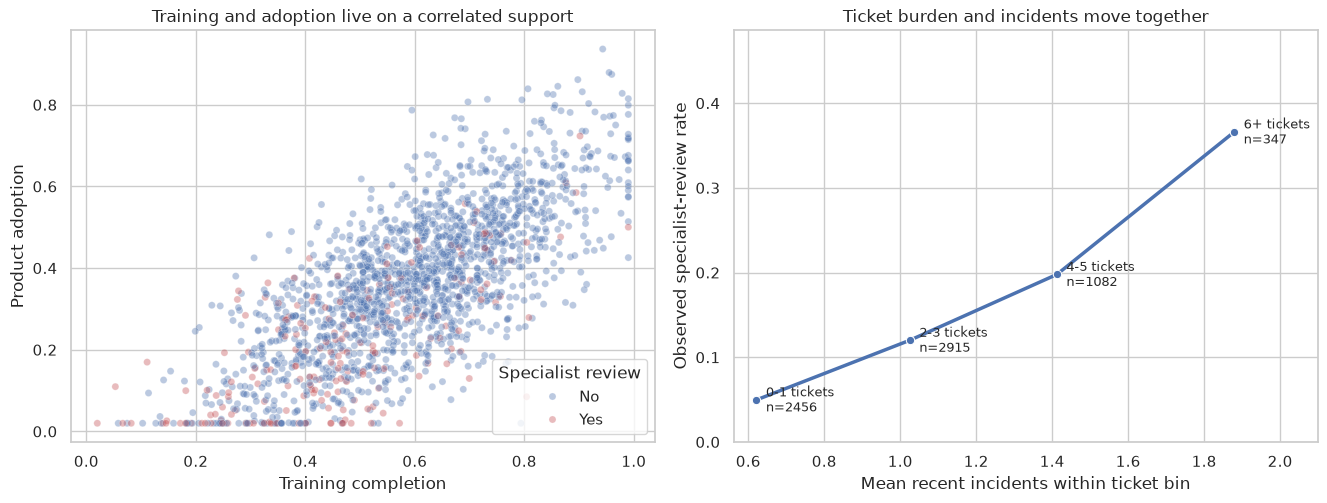

In [3]:
# Section focus: Discussion of The Data Design.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

sample_plot = df.sample(1800, random_state=2030)
sns.scatterplot(
    data=sample_plot,
    x='training_completion',
    y='product_adoption',
    hue=TARGET,
    palette={0: '#4c72b0', 1: '#c44e52'},
    alpha=0.38,
    s=26,
    ax=axes[0],
)
axes[0].set_title('Training and adoption live on a correlated support')
axes[0].set_xlabel('Training completion')
axes[0].set_ylabel('Product adoption')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=['No', 'Yes'], title='Specialist review', loc='lower right')

burden_summary = (
    df.assign(ticket_bin=pd.cut(df['open_tickets_30d'], bins=[-0.1, 1, 3, 5, 12], labels=['0-1', '2-3', '4-5', '6+']))
    .groupby('ticket_bin', observed=True)
    .agg(mean_incidents=('recent_incidents_90d', 'mean'), review_rate=(TARGET, 'mean'), rows=(TARGET, 'size'))
    .reset_index()
)
sns.lineplot(data=burden_summary, x='mean_incidents', y='review_rate', marker='o', linewidth=2.5, ax=axes[1])
for _, row in burden_summary.iterrows():
    axes[1].text(row['mean_incidents'] + 0.025, row['review_rate'], f"{row['ticket_bin']} tickets\nn={int(row['rows'])}", fontsize=9, va='center')
axes[1].set_title('Ticket burden and incidents move together')
axes[1].set_xlabel('Mean recent incidents within ticket bin')
axes[1].set_ylabel('Observed specialist-review rate')
axes[1].set_xlim(burden_summary['mean_incidents'].min() - 0.06, burden_summary['mean_incidents'].max() + 0.22)
axes[1].set_ylim(0, min(0.8, burden_summary['review_rate'].max() + 0.12))

plt.tight_layout()
plt.show()


For Discussion of The Data Design, read the explanation as something a stakeholder may challenge. Stability, clarity, and sensitivity all matter.


## 3. Fit A Nonlinear Model To Explain

Global explanation plots explain a fitted model, so we first need a fitted model. We use a histogram gradient boosting classifier because it can represent nonlinearities and interactions without producing a simple coefficient table.

The goal is not to maximize benchmark performance. The goal is to have a realistic enough model that global explanations have something nontrivial to reveal.


In [4]:
# Section focus: 3. Fit A Nonlinear Model To Explain.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

gbm = HistGradientBoostingClassifier(
    max_iter=260,
    learning_rate=0.045,
    max_leaf_nodes=24,
    l2_regularization=0.025,
    min_samples_leaf=35,
    random_state=2030,
)
gbm.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=260,
    max_depth=8,
    min_samples_leaf=30,
    random_state=2030,
    n_jobs=-1,
)
rf.fit(X_train, y_train)


def predict_risk(model, X):
    """Carry out the predict risk step used in the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the predict risk calculation.
    """
    return model.predict_proba(X)[:, 1]


model_rows = []
for name, model in [('Gradient boosting model', gbm), ('Random forest benchmark', rf)]:
    pred = predict_risk(model, X_test)
    model_rows.append(
        {
            'model': name,
            'roc_auc': roc_auc_score(y_test, pred),
            'average_precision': average_precision_score(y_test, pred),
            'brier_score': brier_score_loss(y_test, pred),
            'log_loss': log_loss(y_test, pred),
            'mean_predicted_risk': pred.mean(),
        }
    )

model_table = pd.DataFrame(model_rows).sort_values('roc_auc', ascending=False)
smart_display(model_table.round(3))


,model,roc_auc,average_precision,brier_score,log_loss,mean_predicted_risk
1,Random forest benchmark,0.861,0.543,0.078,0.266,0.121
0,Gradient boosting model,0.844,0.509,0.079,0.274,0.112


This result is an interpretation diagnostic. For Fit A Nonlinear Model To Explain, look at whether the explanation is stable, plausible, and useful for stakeholder review. Use the variation across samples and neighborhoods to decide how strongly the explanation can be stated.


### Explanation Target

In the rest of the notebook, $\hat f(x)$ is the gradient boosting model's predicted probability of specialist review. Every curve below is about this learned function.

A careful interpretation sounds like this:

> According to the fitted model, predicted review risk tends to move this way as the feature changes.

A careless interpretation sounds like this:

> Changing this feature would cause review risk to change this way.

The first statement is a model audit claim. The second is a causal claim, and it needs causal design assumptions that PDP, ICE, and ALE do not supply.


## 4. PDP And ICE From First Principles

For feature $j$, the ICE curve for observation $i$ is

$$
\widehat{ICE}_{ij}(z) = \hat f(z, x_{i,-j}).
$$

The PDP is the average of those ICE curves:

$$
\widehat{PD}_j(z) = \frac{1}{n}\sum_{i=1}^n \widehat{ICE}_{ij}(z).
$$

Centered ICE removes each curve's value at a reference grid point $z_0$:

$$
\widehat{cICE}_{ij}(z)
= \widehat{ICE}_{ij}(z) - \widehat{ICE}_{ij}(z_0).
$$

Centered ICE is useful when the curves have different baselines. It emphasizes slope and interaction patterns rather than starting levels.


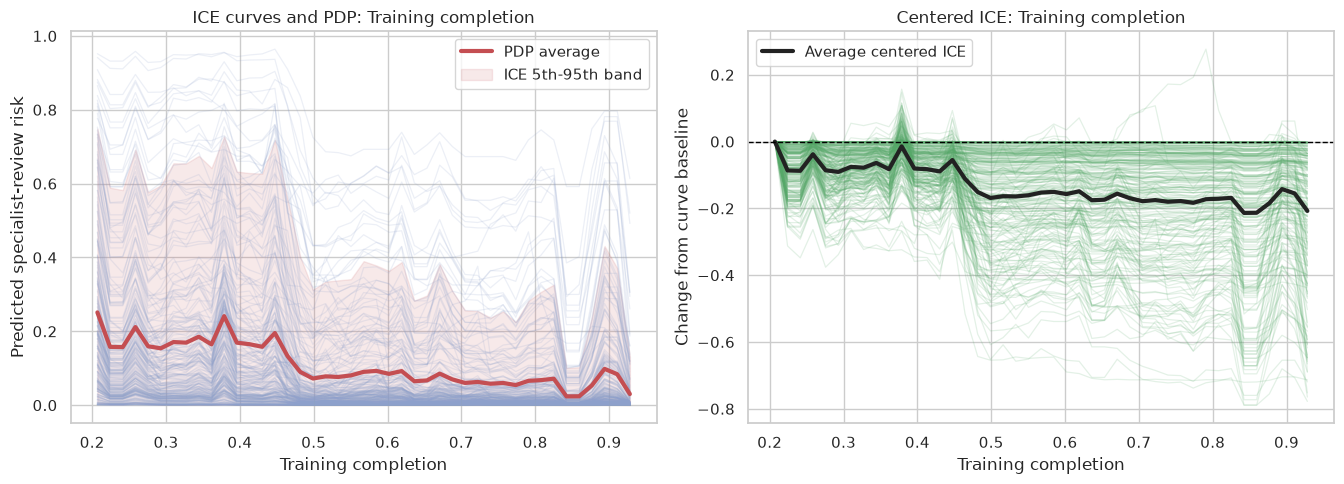

In [5]:
# Section focus: 4. PDP And ICE From First Principles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_grid(series, n=41, q_low=0.02, q_high=0.98):
    """Construct the grid helper used in the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    series : object
        One-dimensional pandas object whose distribution or most common value is being inspected.
    n : object
        Number of observations or simulation units used by the calculation.
    q_low : object
        The q low setting that controls the grid calculation in this notebook.
    q_high : object
        The q high setting that controls the grid calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the grid calculation and reused by later cells.
    """
    lower = series.quantile(q_low)
    upper = series.quantile(q_high)
    return np.linspace(lower, upper, n)


def compute_pdp(model, X, feature, grid):
    """Compute pdp for the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for value in grid:
        X_temp = X.copy()
        X_temp[feature] = value
        preds = predict_risk(model, X_temp)
        rows.append(
            {
                'feature_value': value,
                'pdp': preds.mean(),
                'prediction_sd': preds.std(),
                'p05': np.quantile(preds, 0.05),
                'p95': np.quantile(preds, 0.95),
            }
        )
    return pd.DataFrame(rows)


def compute_ice(model, X, feature, grid, sample_n=260, seed=2030):
    """Compute ice for the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    sample_n : object
        Number of observations sampled for a local explanation or diagnostic.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the ice calculation and reused by later cells.
    """
    rng = np.random.default_rng(seed)
    sample_idx = rng.choice(len(X), size=min(sample_n, len(X)), replace=False)
    X_sample = X.iloc[sample_idx].copy().reset_index(drop=True)

    rows = []
    for row_id, (_, base_row) in enumerate(X_sample.iterrows()):
        X_temp = pd.DataFrame([base_row] * len(grid))
        X_temp[feature] = grid
        preds = predict_risk(model, X_temp)
        for value, pred in zip(grid, preds):
            rows.append({'row_id': row_id, 'feature_value': value, 'prediction': pred})
    ice = pd.DataFrame(rows)
    baseline = ice.loc[ice['feature_value'].eq(grid[0]), ['row_id', 'prediction']].rename(columns={'prediction': 'baseline_prediction'})
    ice = ice.merge(baseline, on='row_id', how='left')
    ice['centered_prediction'] = ice['prediction'] - ice['baseline_prediction']
    return ice


def plot_pdp_ice(model, X, feature, *, grid=None, sample_n=220, seed=2030, title_suffix=''):
    """Draw the pdp ice figure for the 06. Global Explanations: Partial Dependence, ICE, and ALE analysis.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    sample_n : object
        Number of observations sampled for a local explanation or diagnostic.
    seed : object
        Random seed used to make the simulation reproducible.
    title_suffix : object
        Display setting used to make the plot or table readable in the rendered notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    if grid is None:
        grid = make_grid(X[feature])
    pdp = compute_pdp(model, X, feature, grid)
    ice = compute_ice(model, X, feature, grid, sample_n=sample_n, seed=seed)

    fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0), sharex=True)

    for _, curve in ice.groupby('row_id'):
        axes[0].plot(curve['feature_value'], curve['prediction'], color='#8da0cb', alpha=0.16, linewidth=0.9)
    axes[0].plot(pdp['feature_value'], pdp['pdp'], color='#c44e52', linewidth=3.0, label='PDP average')
    axes[0].fill_between(pdp['feature_value'], pdp['p05'], pdp['p95'], color='#c44e52', alpha=0.12, label='ICE 5th-95th band')
    axes[0].set_title(f'ICE curves and PDP: {FEATURE_LABELS[feature]}{title_suffix}')
    axes[0].set_xlabel(FEATURE_LABELS[feature])
    axes[0].set_ylabel('Predicted specialist-review risk')
    axes[0].legend(loc='best')

    for _, curve in ice.groupby('row_id'):
        axes[1].plot(curve['feature_value'], curve['centered_prediction'], color='#55a868', alpha=0.16, linewidth=0.9)
    centered_pdp = ice.groupby('feature_value', as_index=False)['centered_prediction'].mean()
    axes[1].plot(centered_pdp['feature_value'], centered_pdp['centered_prediction'], color='#222222', linewidth=3.0, label='Average centered ICE')
    axes[1].axhline(0, color='black', linewidth=1.0, linestyle='--')
    axes[1].set_title(f'Centered ICE: {FEATURE_LABELS[feature]}')
    axes[1].set_xlabel(FEATURE_LABELS[feature])
    axes[1].set_ylabel('Change from curve baseline')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()
    return pdp, ice

training_grid = make_grid(X_test['training_completion'], n=43)
training_pdp, training_ice = plot_pdp_ice(gbm, X_test, 'training_completion', grid=training_grid, sample_n=240)


This result is an interpretation diagnostic. For PDP And ICE From First Principles, look at whether the explanation is stable, plausible, and useful for stakeholder review. A moving narrative should be treated as diagnostic evidence rather than a settled explanation.


### Discussion of Training Completion Curves

The PDP says that the fitted model generally assigns lower specialist-review risk when training completion is higher. That direction is sensible: better-trained accounts tend to need fewer specialist interventions.

The ICE curves add something the average hides. Some accounts have steep drops as training rises, while others barely move. That difference is a sign of **interaction**: the model's response to training depends on the rest of the account profile.

For decision science, this matters. A global average can support a broad model audit statement, but it should not be the only basis for a targeting rule. If only some accounts have steep curves, a deployment rule should ask who those accounts are.


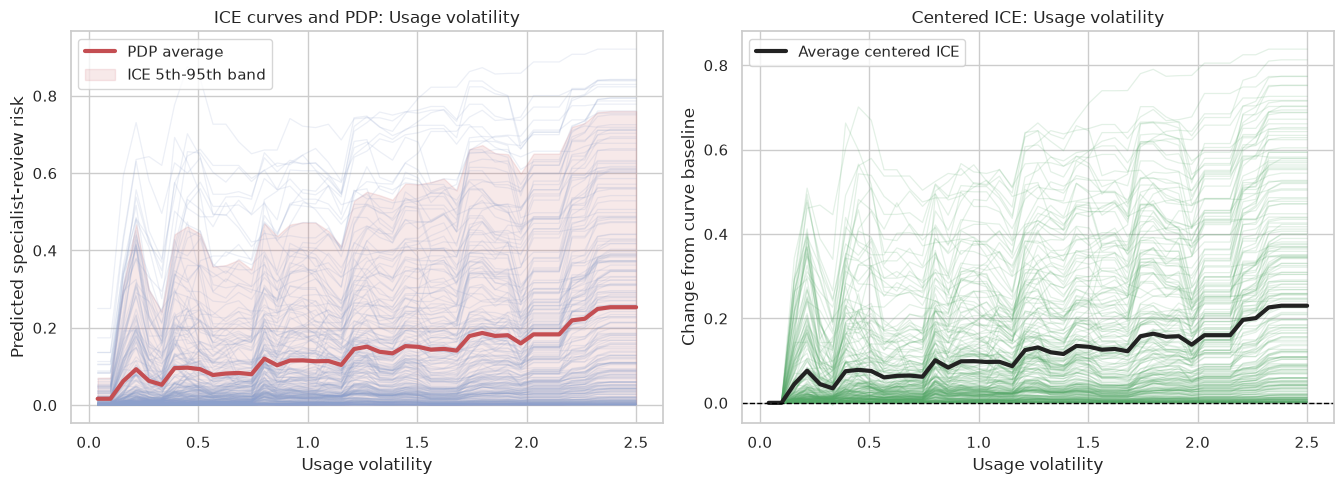

In [6]:
volatility_grid = make_grid(X_test['usage_volatility'], n=43)
volatility_pdp, volatility_ice = plot_pdp_ice(gbm, X_test, 'usage_volatility', grid=volatility_grid, sample_n=240)


Discussion of Training Completion Curves is useful only if the explanation remains credible under reasonable modeling choices.


### Discussion of Usage Volatility Curves

Usage volatility has the opposite direction: predicted risk generally rises as volatility rises. Again, the ICE curves are not parallel. Some accounts are already high risk at low volatility, while others become risky only after volatility rises.

This is the basic diagnostic value of ICE:

- Parallel ICE curves suggest an approximately additive feature effect.
- Fanning, crossing, or slope changes suggest interactions.
- A smooth PDP with highly diverse ICE curves can be a misleading simplification.


## 5. PDP Can Mix Subgroups

A PDP is an average over the empirical distribution of the other features. If a model behaves differently across subgroups, the overall PDP can be a blend of several different response curves.

This is not a bug. It is the definition of the estimand. But it can be a poor communication choice if a decision audience needs subgroup-specific guidance.


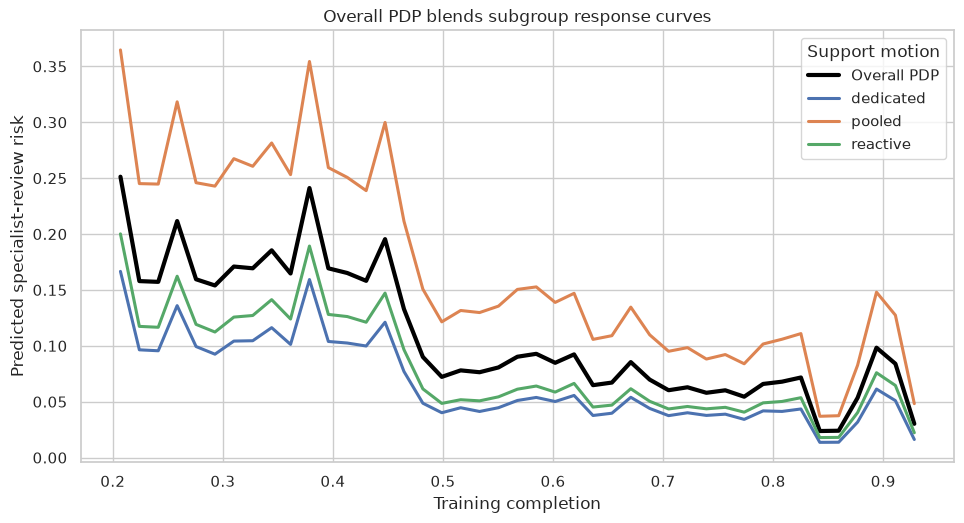

,support_motion,rows,observed_review_rate,mean_predicted_risk,mean_training,mean_adoption
1,pooled,700,0.187,0.198,0.486,0.270
2,reactive,1017,0.088,0.071,0.607,0.366
0,dedicated,323,0.071,0.055,0.658,0.401


In [7]:
# Section focus: 5. PDP Can Mix Subgroups.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def compute_subgroup_pdp(model, X, group_series, feature, grid):
    """Compute subgroup pdp for the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    group_series : object
        The group series setting that controls the subgroup pdp calculation in this notebook.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    
    Returns
    -------
    object
        Intermediate result produced by the subgroup pdp calculation and reused by later cells.
    """
    rows = []
    group_series = pd.Series(group_series).reset_index(drop=True)
    for group_value in sorted(group_series.unique()):
        X_group = X.loc[group_series.eq(group_value)].copy()
        if len(X_group) == 0:
            continue
        pdp_group = compute_pdp(model, X_group, feature, grid)
        pdp_group['group'] = group_value
        pdp_group['rows'] = len(X_group)
        rows.append(pdp_group)
    return pd.concat(rows, ignore_index=True)

support_motion_test = test_df['support_motion'].reset_index(drop=True)
subgroup_pdp = compute_subgroup_pdp(gbm, X_test, support_motion_test, 'training_completion', training_grid)

fig, ax = plt.subplots(figsize=(9.8, 5.4))
sns.lineplot(data=training_pdp.assign(group='Overall'), x='feature_value', y='pdp', linewidth=3.0, color='black', label='Overall PDP', ax=ax)
sns.lineplot(data=subgroup_pdp, x='feature_value', y='pdp', hue='group', linewidth=2.2, ax=ax)
ax.set_title('Overall PDP blends subgroup response curves')
ax.set_xlabel('Training completion')
ax.set_ylabel('Predicted specialist-review risk')
ax.legend(title='Support motion')
plt.tight_layout()
plt.show()

subgroup_table = (
    test_df.assign(predicted_risk=predict_risk(gbm, X_test))
    .groupby('support_motion', as_index=False)
    .agg(
        rows=(TARGET, 'size'),
        observed_review_rate=(TARGET, 'mean'),
        mean_predicted_risk=('predicted_risk', 'mean'),
        mean_training=('training_completion', 'mean'),
        mean_adoption=('product_adoption', 'mean'),
    )
    .sort_values('mean_predicted_risk', ascending=False)
)
smart_display(subgroup_table.round(3))


In PDP Can Mix Subgroups, the explanation should help a reviewer understand what is stable, what is fragile, and what still needs checking. When the story changes under reasonable settings, the report should say so plainly.


### Discussion of Subgroup PDPs

The subgroup curves are close in broad direction but differ in level. That distinction matters:

- The **slope** describes how the model responds as training completion changes.
- The **level** reflects the baseline risk of the subgroup under its other feature distribution.

Stakeholders often want to turn global plots into operational statements such as "improve training to reduce risk." The plot can support a model-audit statement that training is used protectively by the model. It cannot, by itself, prove that a training intervention would reduce risk by the PDP amount.


## 6. Support Diagnostics For Correlated Features

The core weakness of PDP under feature dependence is extrapolation.

For each grid value $z$, the PDP evaluates all rows at $x_j=z$. If $x_j$ is correlated with another feature $x_k$, then many constructed pairs $(z, x_{i,k})$ may be unusual.

Here we diagnose this for training completion and product adoption. At each training value, we look at the adoption range observed among nearby accounts. Then we ask what share of the PDP's constructed rows would have adoption values outside that local range.


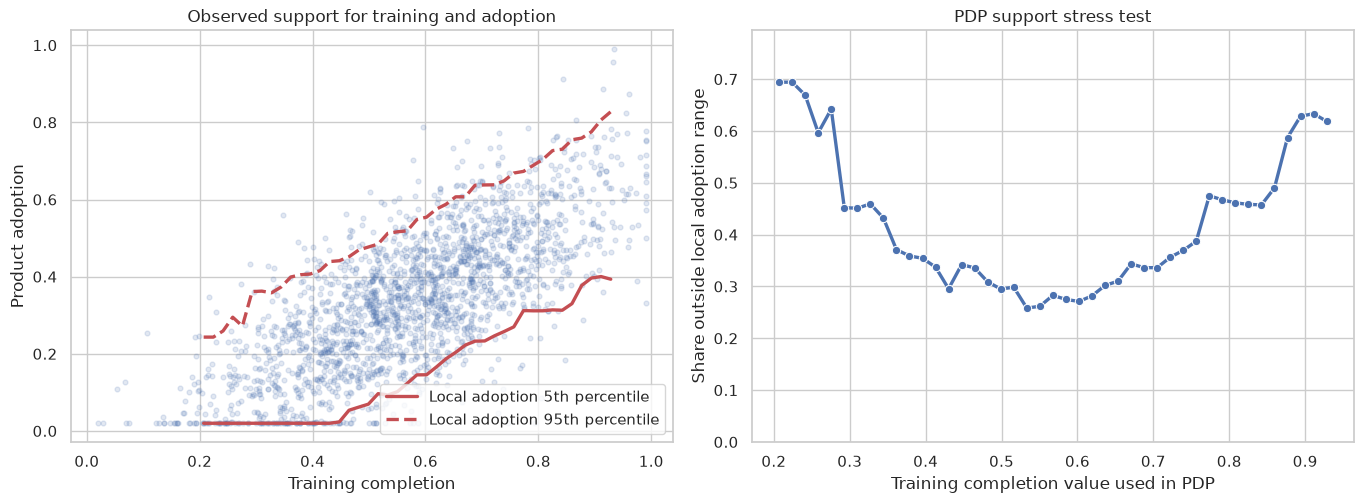

,feature_value,local_companion_p05,local_companion_p95,constructed_rows_outside_local_range,local_rows_used
0,0.207000,0.020000,0.243000,0.694000,80
7,0.327000,0.020000,0.358000,0.459000,165
14,0.447000,0.024000,0.441000,0.342000,294
21,0.568000,0.123000,0.519000,0.283000,365
28,0.688000,0.233000,0.637000,0.336000,338
35,0.808000,0.312000,0.704000,0.461000,187
42,0.928000,0.393000,0.827000,0.619000,80


In [8]:
# Section focus: 6. Support Diagnostics For Correlated Features.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def local_support_diagnostic(X, feature, companion, grid, window=0.045, min_local=80):
    """Carry out the local support diagnostic step used in the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    feature : object
        Column or variable name used to select information from the input table.
    companion : object
        The companion setting that controls the local support diagnostic calculation in this notebook.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    window : object
        Time window or row window over which the diagnostic is computed.
    min_local : object
        The min local setting that controls the local support diagnostic calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    feature_values = X[feature].to_numpy()
    companion_values = X[companion].to_numpy()

    for value in grid:
        local_mask = np.abs(feature_values - value) <= window
        if local_mask.sum() < min_local:
            nearest = np.argsort(np.abs(feature_values - value))[:min_local]
            local_companion = companion_values[nearest]
        else:
            local_companion = companion_values[local_mask]

        local_low, local_high = np.quantile(local_companion, [0.05, 0.95])
        outside_share = np.mean((companion_values < local_low) | (companion_values > local_high))
        rows.append(
            {
                'feature_value': value,
                'local_companion_p05': local_low,
                'local_companion_p95': local_high,
                'constructed_rows_outside_local_range': outside_share,
                'local_rows_used': max(int(local_mask.sum()), min_local),
            }
        )
    return pd.DataFrame(rows)

support_diag = local_support_diagnostic(X_test, 'training_completion', 'product_adoption', training_grid)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))

axes[0].scatter(X_test['training_completion'], X_test['product_adoption'], s=12, alpha=0.16, color='#4c72b0')
axes[0].plot(support_diag['feature_value'], support_diag['local_companion_p05'], color='#c44e52', linewidth=2.4, label='Local adoption 5th percentile')
axes[0].plot(support_diag['feature_value'], support_diag['local_companion_p95'], color='#c44e52', linewidth=2.4, linestyle='--', label='Local adoption 95th percentile')
axes[0].set_title('Observed support for training and adoption')
axes[0].set_xlabel('Training completion')
axes[0].set_ylabel('Product adoption')
axes[0].legend(loc='lower right')

sns.lineplot(data=support_diag, x='feature_value', y='constructed_rows_outside_local_range', marker='o', linewidth=2.4, ax=axes[1])
axes[1].set_title('PDP support stress test')
axes[1].set_xlabel('Training completion value used in PDP')
axes[1].set_ylabel('Share outside local adoption range')
axes[1].set_ylim(0, min(1.0, support_diag['constructed_rows_outside_local_range'].max() + 0.10))

plt.tight_layout()
plt.show()

smart_display(support_diag.iloc[::7].round(3))


The explanation result should be compared with the decision story. In Support Diagnostics For Correlated Features, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Good explanations reduce ambiguity for stakeholders. Weak ones push the burden back onto human reviewers.


### Discussion of Support Diagnostics

This diagnostic does not say that PDP is invalid. It says that the PDP is partly asking the model to score unusual combinations.

At low training values, the local adoption range is also low. At high training values, adoption is typically higher. But a PDP for training completion holds adoption fixed for every row while sweeping training across the grid. That can pair low training with adoption values typical of mature accounts, and high training with adoption values typical of immature accounts.

This is why PDP is best read as a **model query average**, not as a realistic account-evolution story.


## 7. ALE: Accumulated Local Effects

ALE was proposed to reduce the extrapolation problem of PDP under correlated predictors. Instead of replacing a feature for every observation at every grid value, ALE estimates local changes inside intervals of the observed feature distribution.

For a continuous feature $x_j$, the population first-order ALE function can be written as

$$
f_{j,ALE}(z)
= \int_{z_0}^{z}
\mathbb{E}\left[
\frac{\partial \hat f(X)}{\partial x_j}
\mid X_j=t
\right]dt - C,
$$

where $C$ centers the function.

An empirical bin-based approximation works like this:

1. Divide $x_j$ into intervals $[a_{k-1}, a_k]$.
2. For observations whose $x_j$ lies in interval $k$, compute the local model difference

$$
\hat f(a_k, x_{i,-j}) - \hat f(a_{k-1}, x_{i,-j}).
$$

3. Average those local differences within each interval.
4. Accumulate the interval averages across the feature range.
5. Center the result so the average ALE value is zero.

The key difference from PDP is that ALE uses observations only in the local interval where the feature value is actually observed.


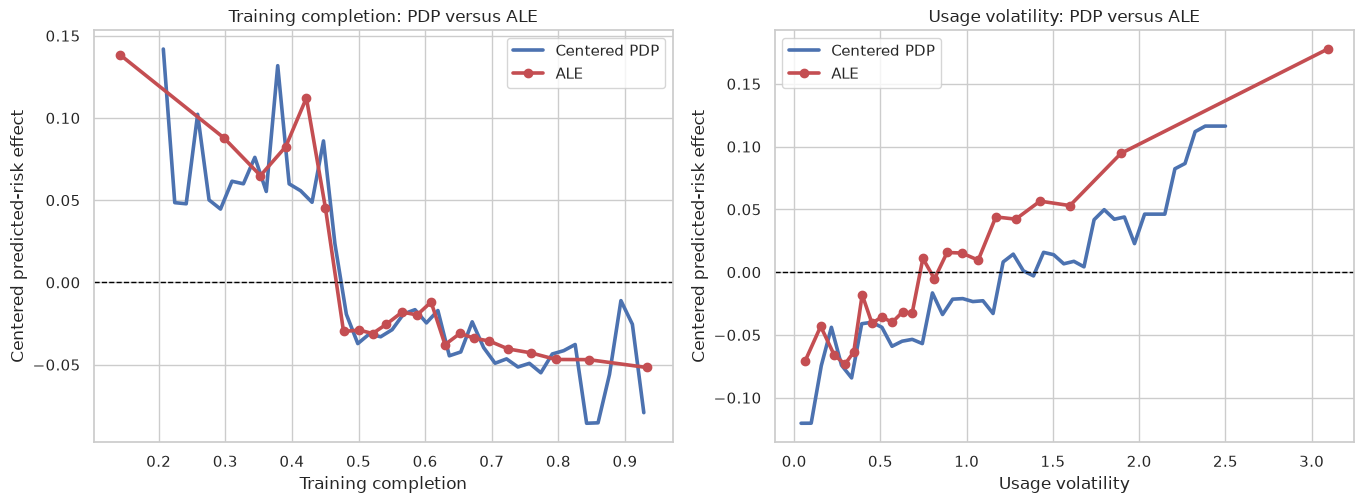

,bin,left_edge,right_edge,rows,average_local_difference,ale_centered
0,1,0.020,0.264,93,-0.001,0.138
1,2,0.264,0.332,93,-0.051,0.088
2,3,0.332,0.374,93,-0.023,0.065
3,4,0.374,0.407,92,0.018,0.083
4,5,0.407,0.436,93,0.030,0.112
5,6,0.436,0.465,93,-0.067,0.045
6,7,0.465,0.490,92,-0.075,-0.030
7,8,0.490,0.512,93,0.001,-0.029
8,9,0.512,0.530,93,-0.002,-0.031
9,10,0.530,0.553,92,0.006,-0.025


In [9]:
# Section focus: 7. ALE: Accumulated Local Effects.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def compute_ale_1d(model, X, feature, n_bins=22):
    """Compute ale 1d for the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    feature : object
        Column or variable name used to select information from the input table.
    n_bins : object
        Count or size setting for the ale 1d calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the ale 1d calculation and reused by later cells.
    """
    x = X[feature].to_numpy()
    edges = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    if len(edges) < 3:
        raise ValueError(f'Feature {feature} does not have enough unique values for ALE.')

    bin_id = np.digitize(x, edges[1:-1], right=True)
    rows = []

    for k in range(len(edges) - 1):
        idx = np.where(bin_id == k)[0]
        if len(idx) == 0:
            continue
        left = edges[k]
        right = edges[k + 1]
        X_left = X.iloc[idx].copy()
        X_right = X.iloc[idx].copy()
        X_left[feature] = left
        X_right[feature] = right
        local_diff = predict_risk(model, X_right) - predict_risk(model, X_left)
        rows.append(
            {
                'bin': k + 1,
                'left_edge': left,
                'right_edge': right,
                'midpoint': 0.5 * (left + right),
                'rows': len(idx),
                'average_local_difference': local_diff.mean(),
                'sd_local_difference': local_diff.std(),
            }
        )

    ale = pd.DataFrame(rows)
    ale['accumulated_effect'] = ale['average_local_difference'].cumsum()
    center = np.average(ale['accumulated_effect'], weights=ale['rows'])
    ale['ale_centered'] = ale['accumulated_effect'] - center
    return ale


def centered_pdp_for_comparison(pdp):
    """Carry out the centered pdp for comparison step used in the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    pdp : object
        The pdp setting that controls the centered pdp for comparison calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the centered pdp for comparison calculation and reused by later cells.
    """
    out = pdp.copy()
    out['pdp_centered'] = out['pdp'] - out['pdp'].mean()
    return out

training_ale = compute_ale_1d(gbm, X_test, 'training_completion', n_bins=22)
training_pdp_centered = centered_pdp_for_comparison(training_pdp)

volatility_ale = compute_ale_1d(gbm, X_test, 'usage_volatility', n_bins=22)
volatility_pdp_centered = centered_pdp_for_comparison(volatility_pdp)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))

axes[0].plot(training_pdp_centered['feature_value'], training_pdp_centered['pdp_centered'], color='#4c72b0', linewidth=2.6, label='Centered PDP')
axes[0].plot(training_ale['midpoint'], training_ale['ale_centered'], color='#c44e52', linewidth=2.6, marker='o', label='ALE')
axes[0].axhline(0, color='black', linewidth=1.0, linestyle='--')
axes[0].set_title('Training completion: PDP versus ALE')
axes[0].set_xlabel('Training completion')
axes[0].set_ylabel('Centered predicted-risk effect')
axes[0].legend(loc='best')

axes[1].plot(volatility_pdp_centered['feature_value'], volatility_pdp_centered['pdp_centered'], color='#4c72b0', linewidth=2.6, label='Centered PDP')
axes[1].plot(volatility_ale['midpoint'], volatility_ale['ale_centered'], color='#c44e52', linewidth=2.6, marker='o', label='ALE')
axes[1].axhline(0, color='black', linewidth=1.0, linestyle='--')
axes[1].set_title('Usage volatility: PDP versus ALE')
axes[1].set_xlabel('Usage volatility')
axes[1].set_ylabel('Centered predicted-risk effect')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

smart_display(training_ale[['bin', 'left_edge', 'right_edge', 'rows', 'average_local_difference', 'ale_centered']].round(4).head(10))


This result is an interpretation diagnostic. For ALE: Accumulated Local Effects, look at whether the explanation is stable, plausible, and useful for stakeholder review. This is a sign that the explanation is still a working hypothesis.


### Discussion of ALE Versus PDP

The ALE and PDP curves agree on the broad direction in this run: more training completion is associated with lower model-predicted risk, and higher usage volatility is associated with higher model-predicted risk.

The curves need not be identical. PDP asks a global replacement question. ALE asks a local-difference question within observed intervals.

The practical rule is:

- If features are weakly correlated and support is broad, PDP is often easy to communicate.
- If features are strongly correlated, ALE is usually a safer first diagnostic.
- If the audience needs heterogeneity, show ICE or subgroup PDPs rather than only a single global curve.


## 8. Two-Way Partial Dependence

One-way plots can hide interactions. A two-way PDP summarizes the model over a grid of two features:

$$
\widehat{PD}_{j,k}(z_j,z_k)
= \frac{1}{n}\sum_{i=1}^n \hat f(z_j,z_k,x_{i,-\{j,k\}}).
$$

This can reveal whether two features combine additively or interactively. But the support warning becomes stronger, not weaker: a two-way grid can contain many combinations that are rare or impossible.


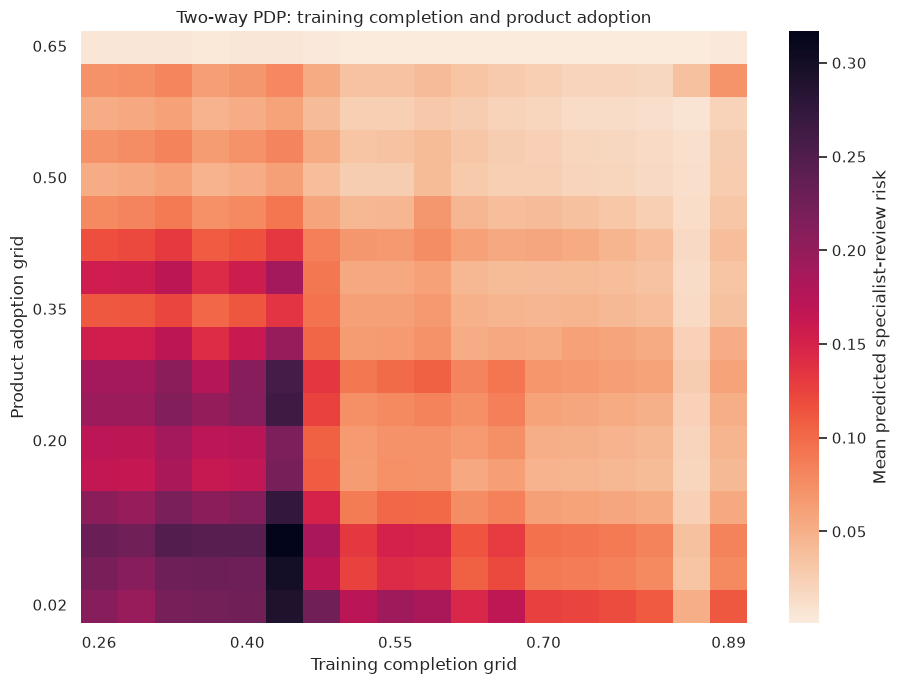

In [10]:
# Section focus: 8. Two-Way Partial Dependence.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def compute_pdp_2d(model, X, feature_x, feature_y, grid_x, grid_y):
    """Compute pdp 2d for the 06. Global Explanations: Partial Dependence, ICE, and ALE workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    feature_x : object
        Column or variable name used to select information from the input table.
    feature_y : object
        Column or variable name used to select information from the input table.
    grid_x : object
        The grid x setting that controls the pdp 2d calculation in this notebook.
    grid_y : object
        The grid y setting that controls the pdp 2d calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for x_value in grid_x:
        for y_value in grid_y:
            X_temp = X.copy()
            X_temp[feature_x] = x_value
            X_temp[feature_y] = y_value
            rows.append(
                {
                    feature_x: x_value,
                    feature_y: y_value,
                    'pdp': predict_risk(model, X_temp).mean(),
                }
            )
    return pd.DataFrame(rows)

training_grid_2d = make_grid(X_test['training_completion'], n=18, q_low=0.04, q_high=0.96)
adoption_grid_2d = make_grid(X_test['product_adoption'], n=18, q_low=0.04, q_high=0.96)
pdp_2d = compute_pdp_2d(gbm, X_test, 'training_completion', 'product_adoption', training_grid_2d, adoption_grid_2d)
heatmap_data = pdp_2d.pivot(index='product_adoption', columns='training_completion', values='pdp')

fig, ax = plt.subplots(figsize=(9.4, 7.0))
sns.heatmap(
    heatmap_data.sort_index(ascending=False),
    cmap='rocket_r',
    cbar_kws={'label': 'Mean predicted specialist-review risk'},
    ax=ax,
)
ax.set_title('Two-way PDP: training completion and product adoption')
ax.set_xlabel('Training completion grid')
ax.set_ylabel('Product adoption grid')

x_tick_positions = np.linspace(0, len(training_grid_2d) - 1, 5).astype(int)
y_tick_positions = np.linspace(0, len(adoption_grid_2d) - 1, 5).astype(int)
ax.set_xticks(x_tick_positions + 0.5)
ax.set_xticklabels([f'{training_grid_2d[i]:.2f}' for i in x_tick_positions], rotation=0)
ax.set_yticks(y_tick_positions + 0.5)
ax.set_yticklabels([f'{adoption_grid_2d[::-1][i]:.2f}' for i in y_tick_positions], rotation=0)
plt.tight_layout()
plt.show()


For Two-Way Partial Dependence, the right question is whether this explanation can survive baseline, sample, or neighborhood changes.


### Discussion of The Two-Way Surface

The heatmap shows a model surface, not a field experiment. The model predicts the highest review risk when both training completion and product adoption are low. The predicted risk falls as either maturity signal improves, with the lowest risk in the upper-right region.

This is useful for model debugging because it confirms that the fitted model learned a coherent maturity-risk surface. It is not enough to claim that increasing both variables would produce the same reduction in real-world risk. That would require assumptions about how training, adoption, support motion, customer maturity, and unmeasured account conditions co-move under an actual intervention.


## 9. Compare With Scikit-Learn's Built-In PDP

The custom functions above make the estimands transparent. In production analysis, you will often use library implementations. Scikit-learn provides `PartialDependenceDisplay` for PDP and ICE.

The important point is not the plotting API. The important point is knowing what is being averaged, what data distribution is being used, and whether the displayed feature combinations are plausible.


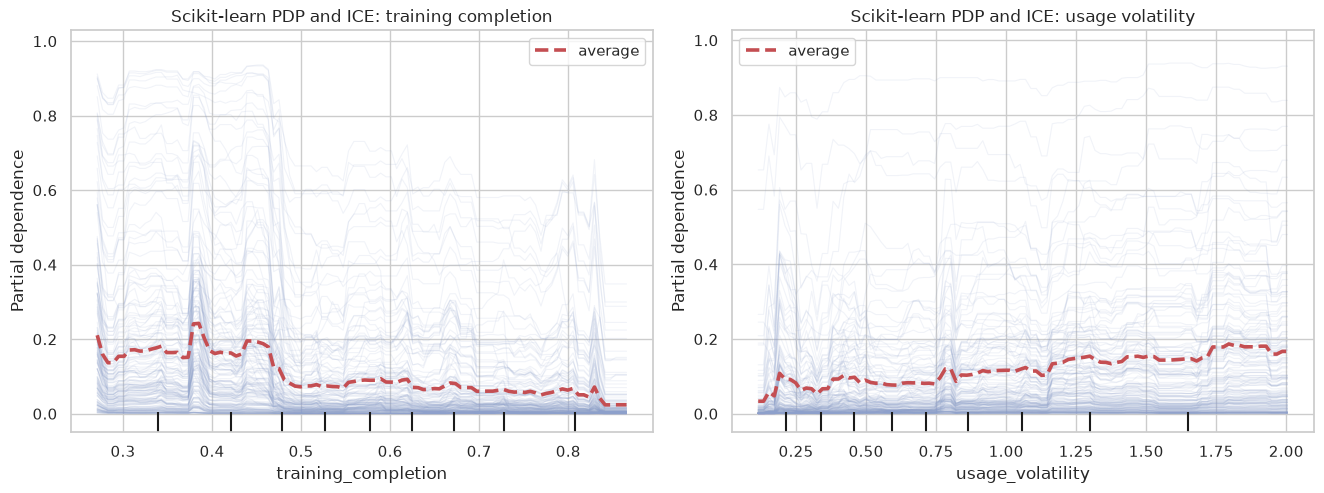

In [11]:
# Section focus: 9. Compare With Scikit-Learn's Built-In PDP.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.1))
PartialDependenceDisplay.from_estimator(
    gbm,
    X_test,
    features=['training_completion'],
    kind='both',
    subsample=180,
    random_state=2030,
    ax=axes[0],
    line_kw={'color': '#c44e52', 'linewidth': 2.6},
    ice_lines_kw={'color': '#8da0cb', 'alpha': 0.12, 'linewidth': 0.8},
)
axes[0].set_title('Scikit-learn PDP and ICE: training completion')
axes[0].set_xlabel('Training completion')
axes[0].set_ylabel('Predicted risk')

PartialDependenceDisplay.from_estimator(
    gbm,
    X_test,
    features=['usage_volatility'],
    kind='both',
    subsample=180,
    random_state=2031,
    ax=axes[1],
    line_kw={'color': '#c44e52', 'linewidth': 2.6},
    ice_lines_kw={'color': '#8da0cb', 'alpha': 0.12, 'linewidth': 0.8},
)
axes[1].set_title('Scikit-learn PDP and ICE: usage volatility')
axes[1].set_xlabel('Usage volatility')
axes[1].set_ylabel('Predicted risk')

plt.tight_layout()
plt.show()


Compare With Scikit-Learn's Built-In PDP is a check on the model narrative. The explanation is useful when the reasons fit the data story, the decision context, and the limits of the method.


## 10. Decision-Science Interpretation Checklist

Static explanation plots become valuable when they feed a disciplined review process.

| Question | PDP | ICE | ALE |
|---|---|---|---|
| What is the average model response to this feature? | Strong | Weak as a summary, strong as raw material | Strong but local-effect based |
| Does the response differ across accounts? | Usually hides this | Strong | Limited unless extended |
| Is the method robust to correlated features? | Weakest | Weakest if interpreted globally | Stronger |
| Is it easy to explain to nontechnical stakeholders? | Strong | Moderate | Moderate to hard |
| Does it estimate a causal intervention effect? | No | No | No |
| Best use in a model review | High-level story | Heterogeneity diagnosis | Safer global diagnosis under dependence |

A good workflow is often:

1. Start with PDP for communication.
2. Add ICE to check heterogeneity.
3. Add support diagnostics when features are correlated.
4. Add ALE when PDP may be extrapolating.
5. Use causal methods if the question is about changing the world rather than explaining the model.


## 11. Explanation Failure Modes

Global explanation plots can fail in several ways.

| Failure mode | Symptom | Better response |
|---|---|---|
| Average hides heterogeneity | PDP is smooth but ICE curves cross or fan out | Show ICE, centered ICE, or subgroup PDP |
| Feature dependence creates unrealistic grid points | PDP uses combinations outside observed support | Show support diagnostics and ALE |
| Plot is read causally | Stakeholder says the feature change will produce the curve's change | Reframe as a model-response summary and require causal design for intervention claims |
| High-risk region has little data | Curve is driven by sparse tail predictions | Add rug plots, bin counts, or confidence bands |
| Feature is a proxy | Curve reflects social, operational, or governance structure | Audit subgroups and policy implications |
| Explanation disagrees with domain logic | Curve violates known monotonicity or business constraints | Revisit data leakage, model class, constraints, or feature engineering |

The purpose of these diagnostics is not to make a black-box model feel safe. It is to make its behavior inspectable enough that analysts can decide whether it deserves trust, revision, or rejection.


In [12]:
# Section focus: 11. Explanation Failure Modes.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

explanation_review = pd.DataFrame(
    [
        {
            'finding': 'Training completion has a negative model-response curve',
            'evidence': 'PDP, ICE average, and ALE move downward as training completion increases',
            'decision_implication': 'The model treats enablement maturity as protective, which is domain-plausible',
            'caution': 'Do not interpret the slope as the causal effect of a training intervention',
        },
        {
            'finding': 'Usage volatility has a positive model-response curve',
            'evidence': 'PDP and ALE rise across the volatility range',
            'decision_implication': 'Volatility can be monitored as a global risk signal',
            'caution': 'High volatility may be a symptom of deeper operational problems',
        },
        {
            'finding': 'Training and adoption are correlated',
            'evidence': 'Support diagnostic shows some PDP grid values create unusual combinations',
            'decision_implication': 'Use ALE or subgroup views when presenting training effects',
            'caution': 'Avoid telling a story about account evolution from PDP alone',
        },
        {
            'finding': 'Subgroup levels differ',
            'evidence': 'Support-motion PDPs have similar directions but different baseline risks',
            'decision_implication': 'A single global curve should not be the only stakeholder-facing explanation',
            'caution': 'Operational policy may require subgroup-specific thresholds',
        },
    ]
)
smart_display(explanation_review)


,finding,evidence,decision_implication,caution
0,Training completion has a negative model-response curve,"PDP, ICE average, and ALE move downward as training completion increases","The model treats enablement maturity as protective, which is domain-plausible",Do not interpret the slope as the causal effect of a training intervention
1,Usage volatility has a positive model-response curve,PDP and ALE rise across the volatility range,Volatility can be monitored as a global risk signal,High volatility may be a symptom of deeper operational problems
2,Training and adoption are correlated,Support diagnostic shows some PDP grid values create unusual combinations,Use ALE or subgroup views when presenting training effects,Avoid telling a story about account evolution from PDP alone
3,Subgroup levels differ,Support-motion PDPs have similar directions but different baseline risks,A single global curve should not be the only stakeholder-facing explanation,Operational policy may require subgroup-specific thresholds


This result is an interpretation diagnostic. For Explanation Failure Modes, look at whether the explanation is stable, plausible, and useful for stakeholder review. A stable explanation can support action; a moving one should stay in review.


## 12. Key Takeaways

- PDP estimates an average model prediction after replacing a feature with grid values.
- ICE plots show the unit-level curves whose average becomes the PDP.
- Centered ICE makes slope heterogeneity easier to see.
- PDP can be misleading when features are correlated because it may evaluate unrealistic feature combinations.
- ALE accumulates local model changes within observed feature intervals and is often safer under feature dependence.
- Two-way PDPs reveal interactions but can amplify support problems.
- None of these plots is a causal effect estimate.
- In decision systems, explanation plots should trigger review questions: Is the model using a sensible signal? Is the signal stable? Is there empirical support? Is the proposed action actually causal or merely predictive?


## References

- Apley, D. W., & Zhu, J. (2020). *Visualizing the Effects of Predictor Variables in Black Box Supervised Learning Models*. *Journal of the Royal Statistical Society: Series B, 82*(4), 1059-1086. [https://doi.org/10.1111/rssb.12377](https://doi.org/10.1111/rssb.12377)
- Friedman, J. H. (2001). *Greedy function approximation: A gradient boosting machine*. *The Annals of Statistics, 29*(5), 1189-1232. [https://doi.org/10.1214/aos/1013203451](https://doi.org/10.1214/aos/1013203451)
- Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015). *Peeking Inside the Black Box: Visualizing Statistical Learning With Plots of Individual Conditional Expectation*. *Journal of Computational and Graphical Statistics, 24*(1), 44-65. [https://doi.org/10.1080/10618600.2014.907095](https://doi.org/10.1080/10618600.2014.907095)
- Hooker, G. (2007). *Generalized Functional ANOVA Diagnostics for High-Dimensional Functions of Dependent Variables*. *Journal of Computational and Graphical Statistics, 16*(3), 709-732. [https://doi.org/10.1198/106186007X237892](https://doi.org/10.1198/106186007X237892)
- scikit-learn developers. *Partial dependence and individual conditional expectation plots*. [https://scikit-learn.org/stable/modules/partial_dependence.html](https://scikit-learn.org/stable/modules/partial_dependence.html)
